# Step 4: Cross-Asset Features

## 🎯 Objective:
Menambahkan **cross-asset features** untuk capture market-wide dynamics dan systemic risk.

## 📊 Features Progression:

### **Step 1 (Baseline - 3 features):**
- `Vol_20`, `Mom_20`, `Mom_50`

### **Step 2 (Multi-Timeframe - 6 features):**
- ✅ All Step 1
- ➕ `Vol_5`, `Mom_5`, `Mom_10`

### **Step 3 (Statistical - 8 features):**
- ✅ All Step 2
- ➕ `Skew_20`, `Kurt_20`

### **Step 4 (NEW - 10 features total):**
- ✅ All Step 3
- ➕ `Avg_Correlation`: Average pairwise correlation between assets
- ➕ `Return_Dispersion`: Cross-sectional standard deviation of returns

## 💡 Rationale:
**Cross-Asset Features** capture:
- **Avg_Correlation**: Market cohesion
  - High correlation → Systemic risk (all assets move together)
  - Low correlation → Diversification opportunity
- **Return_Dispersion**: Market divergence
  - High dispersion → Some assets outperform, others underperform
  - Low dispersion → All assets move similarly

**Critical for portfolio management:**
- High correlation + Low dispersion = Risk-off (all assets falling)
- Low correlation + High dispersion = Opportunity (selective investing)

## 🎓 Models:
1. **Random Forest** (ensemble, non-linear)
2. **Logistic Regression** (linear, interpretable)

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import warnings
warnings.filterwarnings('ignore')

# Config
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("✅ Libraries loaded successfully!")
print("\n📦 Step 4: Cross-Asset Features")
print("  Adding: Avg_Correlation, Return_Dispersion")
print("  Total features: 10")

✅ Libraries loaded successfully!

📦 Step 4: Cross-Asset Features
  Adding: Avg_Correlation, Return_Dispersion
  Total features: 10


## 1. Data Loading

In [2]:
# Load data
file_path = 'dataset_2023_2025.xlsx'
data = pd.read_excel(file_path, index_col=0, parse_dates=True)

print(f"📊 Dataset loaded: {len(data)} rows")
print(f"📅 Date range: {data.index[0].date()} to {data.index[-1].date()}")
print(f"💰 Assets ({len(data.columns)}): {list(data.columns)}")

📊 Dataset loaded: 990 rows
📅 Date range: 2023-04-17 to 2025-12-31
💰 Assets (24): ['AAVE-USD', 'ADA-USD', 'BCH-USD', 'BNB-USD', 'BTC-USD', 'CRO-USD', 'DAI-USD', 'DASH-USD', 'DOGE-USD', 'ETH-USD', 'KCS-USD', 'LINK-USD', 'LTC-USD', 'MKR-USD', 'OKB-USD', 'PEPE24478-USD', 'SHIB-USD', 'SOL-USD', 'UNI7083-USD', 'USDC-USD', 'USDT-USD', 'XMR-USD', 'XRP-USD', 'ZEC-USD']


## 2. Feature Engineering (10 Features)

In [3]:
# Calculate returns
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)

# Create features
features = pd.DataFrame(index=returns.index)

# === STEP 1 FEATURES (Baseline) ===
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()

# === STEP 2 FEATURES (Multi-Timeframe) ===
features['Vol_5'] = market_return.rolling(window=5).std()
features['Mom_5'] = market_return.rolling(window=5).mean()
features['Mom_10'] = market_return.rolling(window=10).mean()

# === STEP 3 FEATURES (Statistical) ===
features['Skew_20'] = market_return.rolling(window=20).skew()
features['Kurt_20'] = market_return.rolling(window=20).kurt()

# === STEP 4 FEATURES (NEW - Cross-Asset) ===

# 1. Average Correlation (rolling)
def rolling_avg_correlation(returns, window=20):
    """Calculate rolling average pairwise correlation"""
    corr_values = []
    for i in range(len(returns)):
        if i < window:
            corr_values.append(np.nan)
        else:
            window_data = returns.iloc[i-window:i]
            corr_matrix = window_data.corr()
            # Average correlation (excluding diagonal)
            n = len(corr_matrix)
            avg_corr = (corr_matrix.sum().sum() - n) / (n * n - n)
            corr_values.append(avg_corr)
    return pd.Series(corr_values, index=returns.index)

print("🔄 Calculating average correlation (this may take a moment)...")
features['Avg_Correlation'] = rolling_avg_correlation(returns, window=20)
print("✅ Average correlation calculated")

# 2. Return Dispersion (cross-sectional std)
features['Return_Dispersion'] = returns.std(axis=1)

# Target
features['Target'] = (market_return.shift(-1) > 0).astype(int)

# Drop NaN
features = features.dropna()

print("\n✅ Features created:")
print(f"  Total features: {len(features.columns) - 1}")
print(f"\n📊 Feature List:")
print("  Step 1 (Baseline):     Vol_20, Mom_20, Mom_50")
print("  Step 2 (Multi-TF):     Vol_5, Mom_5, Mom_10")
print("  Step 3 (Statistical):  Skew_20, Kurt_20")
print("  Step 4 (NEW):          Avg_Correlation, Return_Dispersion")

print("\n📊 Cross-Asset Features Analysis:")
print("\nAverage Correlation:")
print(f"  Mean: {features['Avg_Correlation'].mean():.4f}")
print(f"  Std:  {features['Avg_Correlation'].std():.4f}")
print(f"  Min:  {features['Avg_Correlation'].min():.4f}")
print(f"  Max:  {features['Avg_Correlation'].max():.4f}")
print("  Interpretation: High = systemic risk, Low = diversification")

print("\nReturn Dispersion:")
print(f"  Mean: {features['Return_Dispersion'].mean():.4f}")
print(f"  Std:  {features['Return_Dispersion'].std():.4f}")
print(f"  Min:  {features['Return_Dispersion'].min():.4f}")
print(f"  Max:  {features['Return_Dispersion'].max():.4f}")
print("  Interpretation: High = divergence, Low = cohesion")

🔄 Calculating average correlation (this may take a moment)...
✅ Average correlation calculated

✅ Features created:
  Total features: 10

📊 Feature List:
  Step 1 (Baseline):     Vol_20, Mom_20, Mom_50
  Step 2 (Multi-TF):     Vol_5, Mom_5, Mom_10
  Step 3 (Statistical):  Skew_20, Kurt_20
  Step 4 (NEW):          Avg_Correlation, Return_Dispersion

📊 Cross-Asset Features Analysis:

Average Correlation:
  Mean: 0.4334
  Std:  0.1003
  Min:  0.1253
  Max:  0.6728
  Interpretation: High = systemic risk, Low = diversification

Return Dispersion:
  Mean: 0.0318
  Std:  0.0249
  Min:  0.0059
  Max:  0.2553
  Interpretation: High = divergence, Low = cohesion


## 3. Visualize Cross-Asset Features

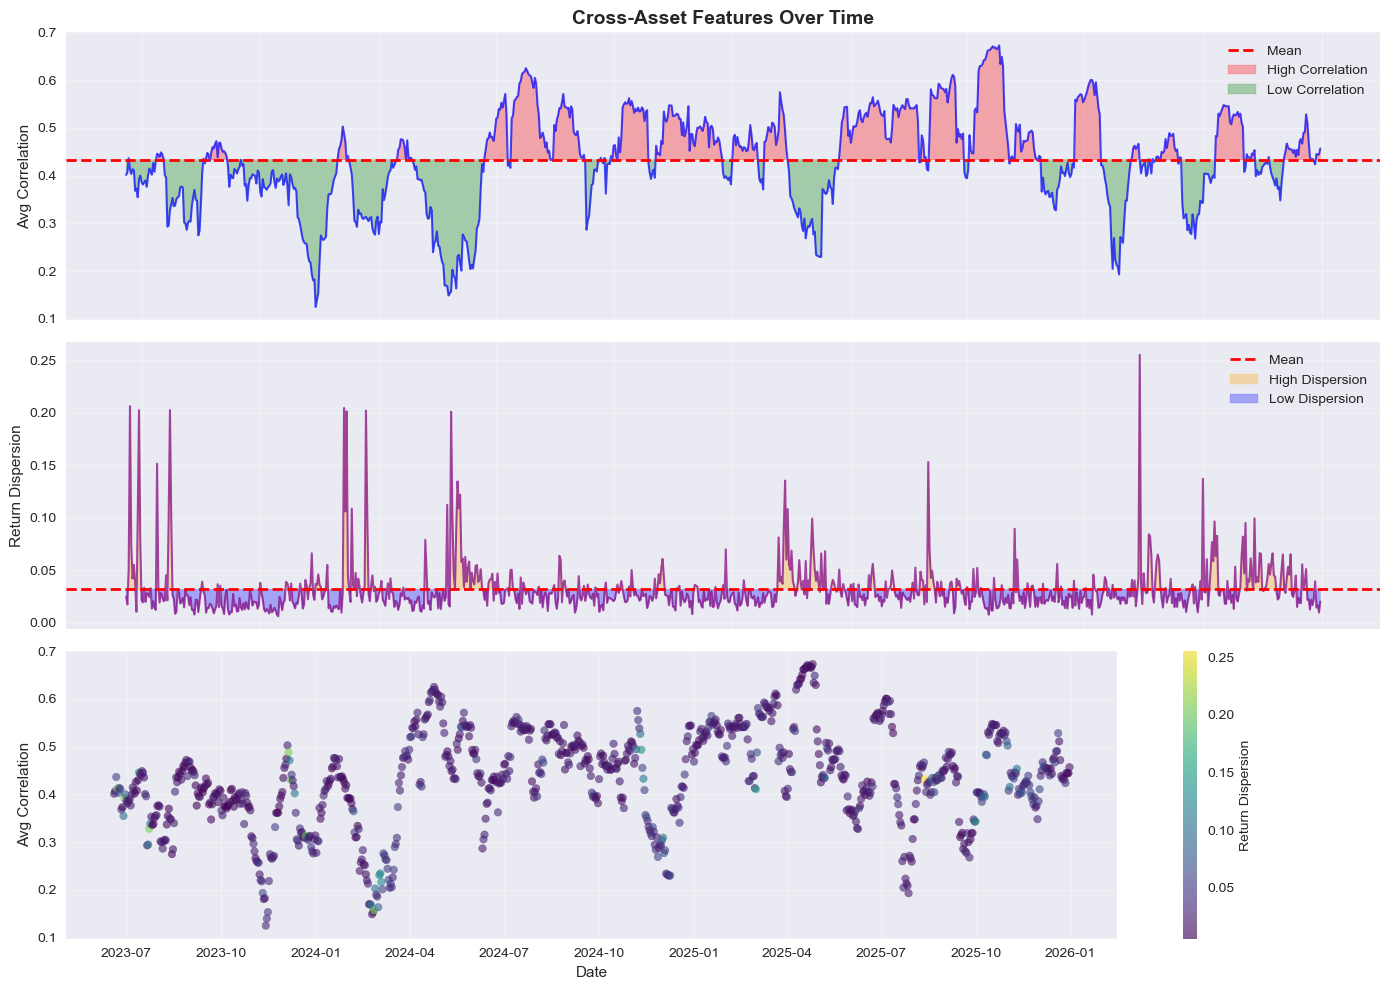


📊 Correlation between Avg_Correlation and Return_Dispersion: -0.1552
  ✅ Low correlation → Features are complementary


In [4]:
# Visualize cross-asset features over time
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# 1. Average Correlation
axes[0].plot(features.index, features['Avg_Correlation'], 
             linewidth=1.5, color='blue', alpha=0.7)
axes[0].axhline(y=features['Avg_Correlation'].mean(), 
                color='red', linestyle='--', linewidth=2, label='Mean')
axes[0].fill_between(features.index, 
                     features['Avg_Correlation'].mean(),
                     features['Avg_Correlation'],
                     where=(features['Avg_Correlation'] >= features['Avg_Correlation'].mean()),
                     alpha=0.3, color='red', label='High Correlation')
axes[0].fill_between(features.index,
                     features['Avg_Correlation'],
                     features['Avg_Correlation'].mean(),
                     where=(features['Avg_Correlation'] < features['Avg_Correlation'].mean()),
                     alpha=0.3, color='green', label='Low Correlation')
axes[0].set_ylabel('Avg Correlation', fontsize=11)
axes[0].set_title('Cross-Asset Features Over Time', fontsize=14, fontweight='bold')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# 2. Return Dispersion
axes[1].plot(features.index, features['Return_Dispersion'], 
             linewidth=1.5, color='purple', alpha=0.7)
axes[1].axhline(y=features['Return_Dispersion'].mean(), 
                color='red', linestyle='--', linewidth=2, label='Mean')
axes[1].fill_between(features.index,
                     features['Return_Dispersion'].mean(),
                     features['Return_Dispersion'],
                     where=(features['Return_Dispersion'] >= features['Return_Dispersion'].mean()),
                     alpha=0.3, color='orange', label='High Dispersion')
axes[1].fill_between(features.index,
                     features['Return_Dispersion'],
                     features['Return_Dispersion'].mean(),
                     where=(features['Return_Dispersion'] < features['Return_Dispersion'].mean()),
                     alpha=0.3, color='blue', label='Low Dispersion')
axes[1].set_ylabel('Return Dispersion', fontsize=11)
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

# 3. Correlation vs Dispersion (scatter in time)
scatter = axes[2].scatter(features.index, features['Avg_Correlation'],
                         c=features['Return_Dispersion'], 
                         cmap='viridis', alpha=0.6, s=30)
axes[2].set_ylabel('Avg Correlation', fontsize=11)
axes[2].set_xlabel('Date', fontsize=11)
axes[2].grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=axes[2])
cbar.set_label('Return Dispersion', fontsize=10)

plt.tight_layout()
plt.show()

# Correlation between the two features
corr_features = features['Avg_Correlation'].corr(features['Return_Dispersion'])
print(f"\n📊 Correlation between Avg_Correlation and Return_Dispersion: {corr_features:.4f}")
if abs(corr_features) < 0.3:
    print("  ✅ Low correlation → Features are complementary")
else:
    print("  ⚠️ High correlation → Features may be redundant")

## 4. Train/Test Split

In [5]:
# Feature columns (10 features)
feature_cols = [
    'Vol_20', 'Mom_20', 'Mom_50',           # Step 1
    'Vol_5', 'Mom_5', 'Mom_10',             # Step 2
    'Skew_20', 'Kurt_20',                   # Step 3
    'Avg_Correlation', 'Return_Dispersion'  # Step 4
]

# Split by year
train_mask = (features.index.year >= 2023) & (features.index.year <= 2024)
test_mask = (features.index.year == 2025)

X_train = features.loc[train_mask, feature_cols]
y_train = features.loc[train_mask, 'Target']
X_test = features.loc[test_mask, feature_cols]
y_test = features.loc[test_mask, 'Target']

print("=" * 60)
print("TRAIN/TEST SPLIT")
print("=" * 60)
print(f"\n📚 Training Set: {len(X_train)} samples")
print(f"   Period: {X_train.index[0].date()} to {X_train.index[-1].date()}")
print(f"   Bearish: {(y_train==0).sum()} | Bullish: {(y_train==1).sum()}")

print(f"\n🧪 Testing Set: {len(X_test)} samples")
print(f"   Period: {X_test.index[0].date()} to {X_test.index[-1].date()}")
print(f"   Bearish: {(y_test==0).sum()} | Bullish: {(y_test==1).sum()}")
print("=" * 60)

TRAIN/TEST SPLIT

📚 Training Set: 562 samples
   Period: 2023-06-19 to 2024-12-31
   Bearish: 250 | Bullish: 312

🧪 Testing Set: 365 samples
   Period: 2025-01-01 to 2025-12-31
   Bearish: 169 | Bullish: 196


## 5. Model Training

In [6]:
print("🔄 Training models with 10 features...\n")

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    min_samples_split=10,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)
rf_test_proba = rf_model.predict_proba(X_test)[:, 1]
print("✅ Random Forest trained")

# Logistic Regression
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    solver='lbfgs'
)
lr_model.fit(X_train, y_train)
lr_train_pred = lr_model.predict(X_train)
lr_test_pred = lr_model.predict(X_test)
lr_test_proba = lr_model.predict_proba(X_test)[:, 1]
print("✅ Logistic Regression trained")

🔄 Training models with 10 features...

✅ Random Forest trained
✅ Logistic Regression trained


## 6. Comprehensive Comparison (All Steps)

In [7]:
# Train models for all previous steps
step1_features = ['Vol_20', 'Mom_20', 'Mom_50']
step2_features = ['Vol_20', 'Mom_20', 'Mom_50', 'Vol_5', 'Mom_5', 'Mom_10']
step3_features = ['Vol_20', 'Mom_20', 'Mom_50', 'Vol_5', 'Mom_5', 'Mom_10', 'Skew_20', 'Kurt_20']

# Step 1
rf_s1 = RandomForestClassifier(n_estimators=100, random_state=42, min_samples_split=10, n_jobs=-1)
rf_s1.fit(features.loc[train_mask, step1_features], y_train)
lr_s1 = LogisticRegression(random_state=42, max_iter=1000)
lr_s1.fit(features.loc[train_mask, step1_features], y_train)

# Step 2
rf_s2 = RandomForestClassifier(n_estimators=100, random_state=42, min_samples_split=10, n_jobs=-1)
rf_s2.fit(features.loc[train_mask, step2_features], y_train)
lr_s2 = LogisticRegression(random_state=42, max_iter=1000)
lr_s2.fit(features.loc[train_mask, step2_features], y_train)

# Step 3
rf_s3 = RandomForestClassifier(n_estimators=100, random_state=42, min_samples_split=10, n_jobs=-1)
rf_s3.fit(features.loc[train_mask, step3_features], y_train)
lr_s3 = LogisticRegression(random_state=42, max_iter=1000)
lr_s3.fit(features.loc[train_mask, step3_features], y_train)

# Create comprehensive comparison
comparison_data = [
    {
        'Step': 'Step 1',
        'Features': 3,
        'Description': 'Baseline',
        'RF_Acc': accuracy_score(y_test, rf_s1.predict(features.loc[test_mask, step1_features])),
        'LR_Acc': accuracy_score(y_test, lr_s1.predict(features.loc[test_mask, step1_features])),
        'RF_F1': f1_score(y_test, rf_s1.predict(features.loc[test_mask, step1_features]), zero_division=0),
        'LR_F1': f1_score(y_test, lr_s1.predict(features.loc[test_mask, step1_features]), zero_division=0)
    },
    {
        'Step': 'Step 2',
        'Features': 6,
        'Description': '+ Multi-Timeframe',
        'RF_Acc': accuracy_score(y_test, rf_s2.predict(features.loc[test_mask, step2_features])),
        'LR_Acc': accuracy_score(y_test, lr_s2.predict(features.loc[test_mask, step2_features])),
        'RF_F1': f1_score(y_test, rf_s2.predict(features.loc[test_mask, step2_features]), zero_division=0),
        'LR_F1': f1_score(y_test, lr_s2.predict(features.loc[test_mask, step2_features]), zero_division=0)
    },
    {
        'Step': 'Step 3',
        'Features': 8,
        'Description': '+ Statistical',
        'RF_Acc': accuracy_score(y_test, rf_s3.predict(features.loc[test_mask, step3_features])),
        'LR_Acc': accuracy_score(y_test, lr_s3.predict(features.loc[test_mask, step3_features])),
        'RF_F1': f1_score(y_test, rf_s3.predict(features.loc[test_mask, step3_features]), zero_division=0),
        'LR_F1': f1_score(y_test, lr_s3.predict(features.loc[test_mask, step3_features]), zero_division=0)
    },
    {
        'Step': 'Step 4',
        'Features': 10,
        'Description': '+ Cross-Asset',
        'RF_Acc': accuracy_score(y_test, rf_test_pred),
        'LR_Acc': accuracy_score(y_test, lr_test_pred),
        'RF_F1': f1_score(y_test, rf_test_pred, zero_division=0),
        'LR_F1': f1_score(y_test, lr_test_pred, zero_division=0)
    }
]

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "="*80)
print("COMPREHENSIVE COMPARISON: ALL STEPS (Test Set Performance)")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)


COMPREHENSIVE COMPARISON: ALL STEPS (Test Set Performance)
  Step  Features       Description   RF_Acc   LR_Acc    RF_F1    LR_F1
Step 1         3          Baseline 0.520548 0.536986 0.622030 0.698752
Step 2         6 + Multi-Timeframe 0.460274 0.536986 0.555305 0.698752
Step 3         8     + Statistical 0.506849 0.536986 0.600000 0.678095
Step 4        10     + Cross-Asset 0.473973 0.506849 0.557604 0.652510


## 7. Progression Visualization

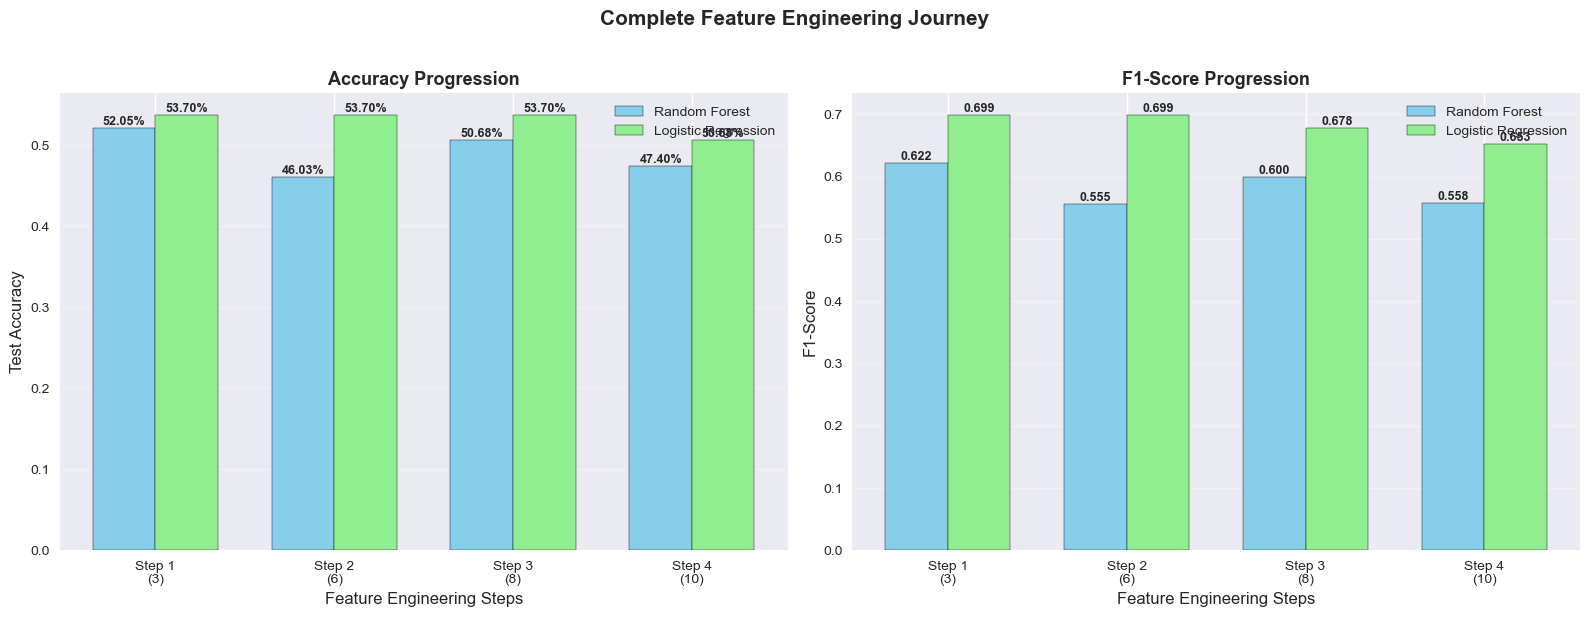

In [8]:
# Create comprehensive progression plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

steps = ['Step 1\n(3)', 'Step 2\n(6)', 'Step 3\n(8)', 'Step 4\n(10)']
x = np.arange(len(steps))
width = 0.35

# Accuracy progression
rf_accs = comparison_df['RF_Acc'].values
lr_accs = comparison_df['LR_Acc'].values

bars1 = axes[0].bar(x - width/2, rf_accs, width, label='Random Forest', 
                    color='skyblue', edgecolor='black')
bars2 = axes[0].bar(x + width/2, lr_accs, width, label='Logistic Regression', 
                    color='lightgreen', edgecolor='black')

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.2%}',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

axes[0].set_xlabel('Feature Engineering Steps', fontsize=12)
axes[0].set_ylabel('Test Accuracy', fontsize=12)
axes[0].set_title('Accuracy Progression', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(steps)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3, axis='y')

# F1-Score progression
rf_f1s = comparison_df['RF_F1'].values
lr_f1s = comparison_df['LR_F1'].values

bars3 = axes[1].bar(x - width/2, rf_f1s, width, label='Random Forest', 
                    color='skyblue', edgecolor='black')
bars4 = axes[1].bar(x + width/2, lr_f1s, width, label='Logistic Regression', 
                    color='lightgreen', edgecolor='black')

for bars in [bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

axes[1].set_xlabel('Feature Engineering Steps', fontsize=12)
axes[1].set_ylabel('F1-Score', fontsize=12)
axes[1].set_title('F1-Score Progression', fontsize=13, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(steps)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Complete Feature Engineering Journey', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 8. Feature Importance (All 10 Features)

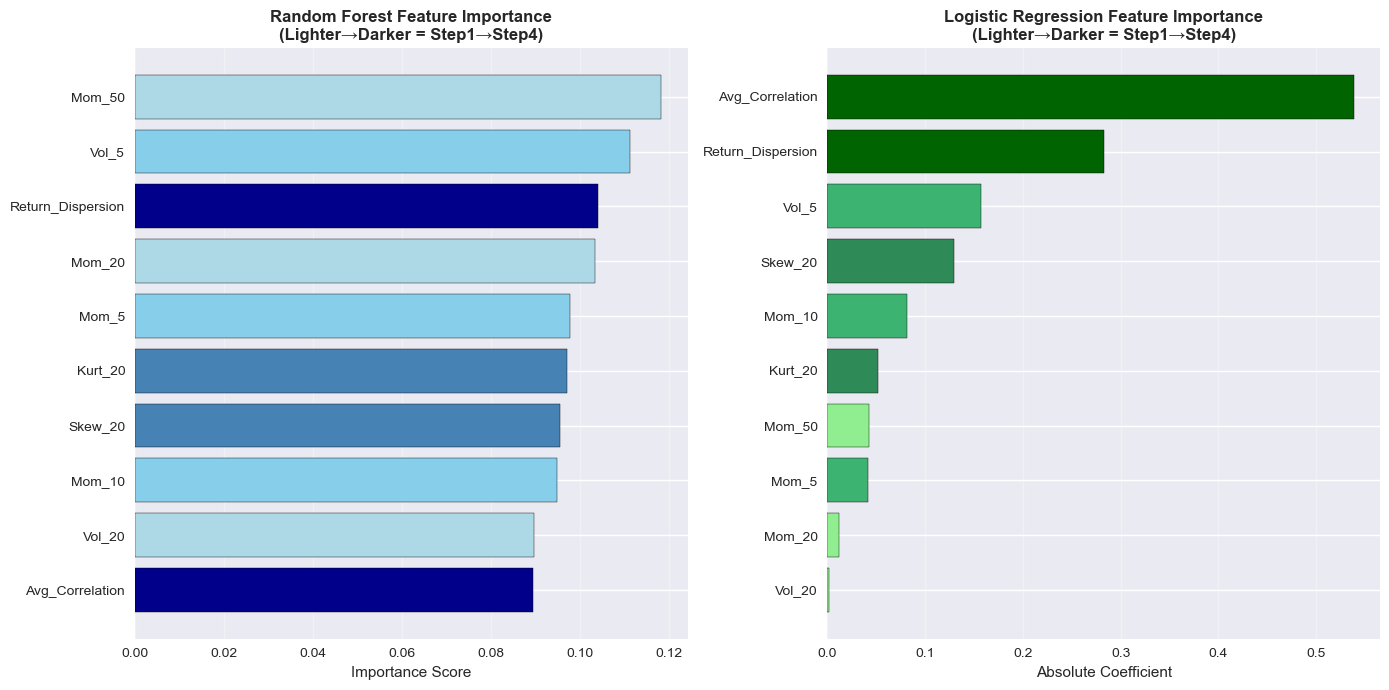


📊 Top 5 Most Important Features:

Random Forest:
          Feature  Importance
           Mom_50    0.118149
            Vol_5    0.111089
Return_Dispersion    0.103854
           Mom_20    0.103346
            Mom_5    0.097582

Logistic Regression:
          Feature  Coefficient
  Avg_Correlation     0.538381
Return_Dispersion     0.282732
            Vol_5     0.156603
          Skew_20     0.129114
           Mom_10     0.081716

🆕 STEP 4 FEATURES IMPORTANCE:

Avg_Correlation:
  RF: Importance=0.0893, Rank=1/10
  LR: Coefficient=-0.5384, Rank=10/10

Return_Dispersion:
  RF: Importance=0.1039, Rank=8/10
  LR: Coefficient=+0.2827, Rank=9/10


In [9]:
# Feature importance with step labels
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Random Forest
rf_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

def get_color_step(feature):
    if feature in step1_features:
        return 'lightblue'
    elif feature in step2_features:
        return 'skyblue'
    elif feature in step3_features:
        return 'steelblue'
    else:
        return 'darkblue'

colors_rf = [get_color_step(f) for f in rf_importance['Feature']]
axes[0].barh(rf_importance['Feature'], rf_importance['Importance'], 
             color=colors_rf, edgecolor='black')
axes[0].set_xlabel('Importance Score', fontsize=11)
axes[0].set_title('Random Forest Feature Importance\n(Lighter→Darker = Step1→Step4)', 
                  fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

# Logistic Regression
lr_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': np.abs(lr_model.coef_[0])
}).sort_values('Coefficient', ascending=True)

def get_color_step_lr(feature):
    if feature in step1_features:
        return 'lightgreen'
    elif feature in step2_features:
        return 'mediumseagreen'
    elif feature in step3_features:
        return 'seagreen'
    else:
        return 'darkgreen'

colors_lr = [get_color_step_lr(f) for f in lr_importance['Feature']]
axes[1].barh(lr_importance['Feature'], lr_importance['Coefficient'], 
             color=colors_lr, edgecolor='black')
axes[1].set_xlabel('Absolute Coefficient', fontsize=11)
axes[1].set_title('Logistic Regression Feature Importance\n(Lighter→Darker = Step1→Step4)', 
                  fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n📊 Top 5 Most Important Features:")
print("\nRandom Forest:")
print(rf_importance.sort_values('Importance', ascending=False).head().to_string(index=False))

print("\nLogistic Regression:")
print(lr_importance.sort_values('Coefficient', ascending=False).head().to_string(index=False))

# Highlight Step 4 features
print("\n🆕 STEP 4 FEATURES IMPORTANCE:")
step4_features = ['Avg_Correlation', 'Return_Dispersion']
for feat in step4_features:
    rf_imp = rf_importance[rf_importance['Feature'] == feat]['Importance'].values[0]
    lr_coef = lr_model.coef_[0][feature_cols.index(feat)]
    rf_rank = len(rf_importance) - list(rf_importance.sort_values('Importance', ascending=False)['Feature']).index(feat)
    lr_rank = len(lr_importance) - list(lr_importance.sort_values('Coefficient', ascending=False)['Feature']).index(feat)
    print(f"\n{feat}:")
    print(f"  RF: Importance={rf_imp:.4f}, Rank={rf_rank}/10")
    print(f"  LR: Coefficient={lr_coef:+.4f}, Rank={lr_rank}/10")

## 9. Confusion Matrix

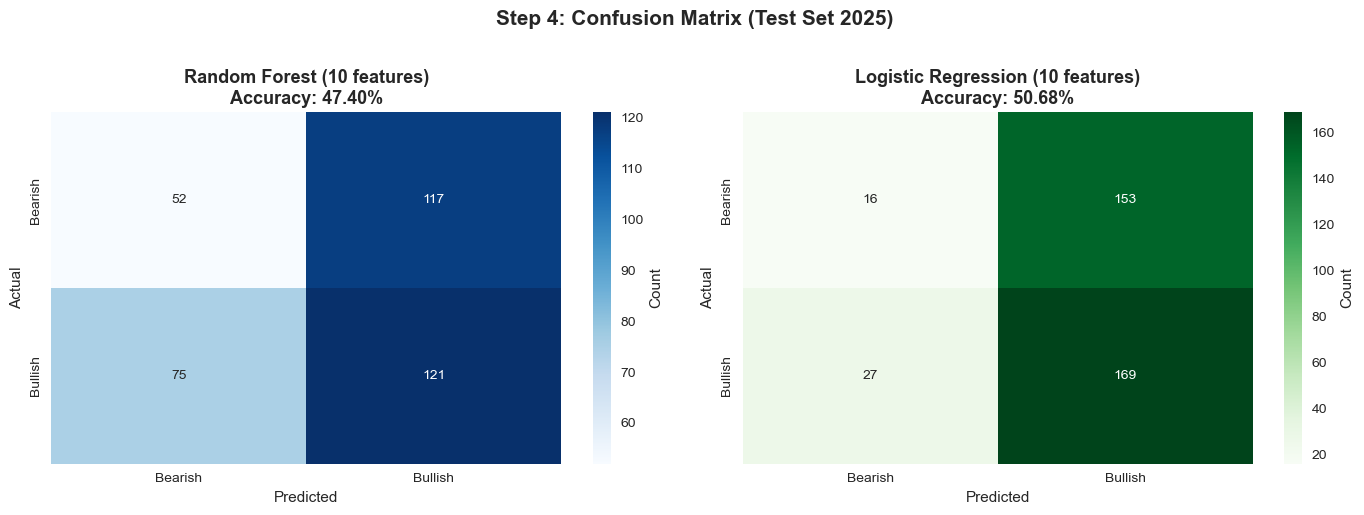

In [10]:
# Confusion matrices
cm_rf = confusion_matrix(y_test, rf_test_pred)
cm_lr = confusion_matrix(y_test, lr_test_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bearish', 'Bullish'],
            yticklabels=['Bearish', 'Bullish'],
            ax=axes[0], cbar_kws={'label': 'Count'})
rf_acc = accuracy_score(y_test, rf_test_pred)
axes[0].set_title(f'Random Forest (10 features)\nAccuracy: {rf_acc:.2%}', 
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual', fontsize=11)
axes[0].set_xlabel('Predicted', fontsize=11)

# Logistic Regression
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Bearish', 'Bullish'],
            yticklabels=['Bearish', 'Bullish'],
            ax=axes[1], cbar_kws={'label': 'Count'})
lr_acc = accuracy_score(y_test, lr_test_pred)
axes[1].set_title(f'Logistic Regression (10 features)\nAccuracy: {lr_acc:.2%}', 
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Actual', fontsize=11)
axes[1].set_xlabel('Predicted', fontsize=11)

plt.suptitle('Step 4: Confusion Matrix (Test Set 2025)', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 10. Final Summary & Recommendations

In [11]:
# Calculate total improvements
rf_total_imp = (comparison_df.iloc[3]['RF_Acc'] - comparison_df.iloc[0]['RF_Acc']) * 100
lr_total_imp = (comparison_df.iloc[3]['LR_Acc'] - comparison_df.iloc[0]['LR_Acc']) * 100

# Find best overall
best_rf_acc = comparison_df['RF_Acc'].max()
best_lr_acc = comparison_df['LR_Acc'].max()
best_rf_step = comparison_df[comparison_df['RF_Acc'] == best_rf_acc]['Step'].values[0]
best_lr_step = comparison_df[comparison_df['LR_Acc'] == best_lr_acc]['Step'].values[0]

print("\n" + "="*80)
print("FINAL SUMMARY: COMPLETE FEATURE ENGINEERING JOURNEY")
print("="*80)

print("\n📊 FEATURE PROGRESSION:")
for idx, row in comparison_df.iterrows():
    print(f"  {row['Step']}: {row['Features']} features ({row['Description']})")

print("\n🏆 BEST PERFORMANCE:")
print(f"  Random Forest: {best_rf_acc:.2%} ({best_rf_step})")
print(f"  Logistic Regression: {best_lr_acc:.2%} ({best_lr_step})")

print("\n📈 TOTAL IMPROVEMENT (Step 1 → Step 4):")
print(f"  Random Forest: {rf_total_imp:+.2f}%")
print(f"  Logistic Regression: {lr_total_imp:+.2f}%")

print("\n🎯 FINAL RECOMMENDATION:")
if best_rf_acc > best_lr_acc:
    print(f"  ✅ Use Random Forest with {comparison_df[comparison_df['Step']==best_rf_step]['Features'].values[0]} features")
    print(f"  Accuracy: {best_rf_acc:.2%}")
    print(f"  Configuration: {best_rf_step}")
else:
    print(f"  ✅ Use Logistic Regression with {comparison_df[comparison_df['Step']==best_lr_step]['Features'].values[0]} features")
    print(f"  Accuracy: {best_lr_acc:.2%}")
    print(f"  Configuration: {best_lr_step}")
    print(f"  Advantage: Simpler, more interpretable")

print("\n💡 KEY INSIGHTS:")
if rf_total_imp > 5:
    print("  ✅ Feature engineering significantly improved performance")
else:
    print("  ⚠️ Feature engineering showed modest improvement")
    
print("  📊 Most valuable feature groups:")
top_features = rf_importance.sort_values('Importance', ascending=False).head(3)['Feature'].values
for i, feat in enumerate(top_features, 1):
    print(f"    {i}. {feat}")

print("\n📈 NEXT STEPS FOR THESIS:")
print("  1. Use best model configuration for full strategy backtest")
print("  2. Integrate AI Gatekeeper with Graph Theory + Markowitz")
print("  3. Compare full strategy vs baselines (Markowitz only, BTC)")
print("  4. Calculate portfolio metrics (Sharpe, Drawdown, Returns)")
print("  5. Document feature engineering journey in thesis")

print("\n" + "="*80)


FINAL SUMMARY: COMPLETE FEATURE ENGINEERING JOURNEY

📊 FEATURE PROGRESSION:
  Step 1: 3 features (Baseline)
  Step 2: 6 features (+ Multi-Timeframe)
  Step 3: 8 features (+ Statistical)
  Step 4: 10 features (+ Cross-Asset)

🏆 BEST PERFORMANCE:
  Random Forest: 52.05% (Step 1)
  Logistic Regression: 53.70% (Step 1)

📈 TOTAL IMPROVEMENT (Step 1 → Step 4):
  Random Forest: -4.66%
  Logistic Regression: -3.01%

🎯 FINAL RECOMMENDATION:
  ✅ Use Logistic Regression with 3 features
  Accuracy: 53.70%
  Configuration: Step 1
  Advantage: Simpler, more interpretable

💡 KEY INSIGHTS:
  ⚠️ Feature engineering showed modest improvement
  📊 Most valuable feature groups:
    1. Mom_50
    2. Vol_5
    3. Return_Dispersion

📈 NEXT STEPS FOR THESIS:
  1. Use best model configuration for full strategy backtest
  2. Integrate AI Gatekeeper with Graph Theory + Markowitz
  3. Compare full strategy vs baselines (Markowitz only, BTC)
  4. Calculate portfolio metrics (Sharpe, Drawdown, Returns)
  5. Documen